# Exploratory Data Analysis (EDA) — Legal Document Simplifier

## Objective
Understand the structure, distribution, and quality of legal clauses
used in the Legal Document Simplifier system.

EDA helps:
- Validate dataset quality
- Understand clause & risk distributions
- Guide modeling decisions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
# Use processed segmented clauses
df = pd.read_csv("../data/processed/cuad_segmented_clauses.csv")

df.head()


,file_name,clause,pages,class_id,label,start_at,end_at,clean_text,sentences,word_count,clause_text
0,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,In the event that Licensor grants to another V...,2,8,Most Favored Nation,2558,2929,in the event that licensor grants to another v...,['in the event that licensor grants to another...,60,in the event that licensor grants to another v...
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,"If Licensor enters, or has entered, into an ag...",8,8,Most Favored Nation,18515,19562,if licensor enters or has entered into an agre...,['if licensor enters or has entered into an ag...,169,if licensor enters or has entered into an agre...
2,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,"Licensor shall provide to Rogers, no later tha...",8,8,Most Favored Nation,19563,20059,licensor shall provide to rogers no later than...,['licensor shall provide to rogers no later th...,79,licensor shall provide to rogers no later than...
3,IntegrityMediaInc_20010329_10-K405_EX-10.17_23...,"If for any reason, Integrity and TL are subjec...",3,8,Most Favored Nation,8173,8345,if for any reason integrity and tl are subject...,['if for any reason integrity and tl are subje...,30,if for any reason integrity and tl are subject...
4,TomOnlineInc_20060501_20-F_EX-4.46_749700_EX-4...,"The Company will, and Online BVI will cause th...",10,8,Most Favored Nation,30765,31577,the company will and online bvi will cause the...,['the company will and online bvi will cause t...,123,the company will and online bvi will cause the...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   file_name    9698 non-null   object
 1   clause       9698 non-null   object
 2   pages        9698 non-null   object
 3   class_id     9698 non-null   int64 
 4   label        9698 non-null   object
 5   start_at     9698 non-null   int64 
 6   end_at       9698 non-null   int64 
 7   clean_text   9698 non-null   object
 8   sentences    9698 non-null   object
 9   word_count   9698 non-null   int64 
 10  clause_text  9698 non-null   object
dtypes: int64(4), object(7)
memory usage: 833.6+ KB


In [5]:
print("Total clauses:", len(df))
print("Unique clause types:", df["label"].nunique())


Total clauses: 9698
Unique clause types: 41


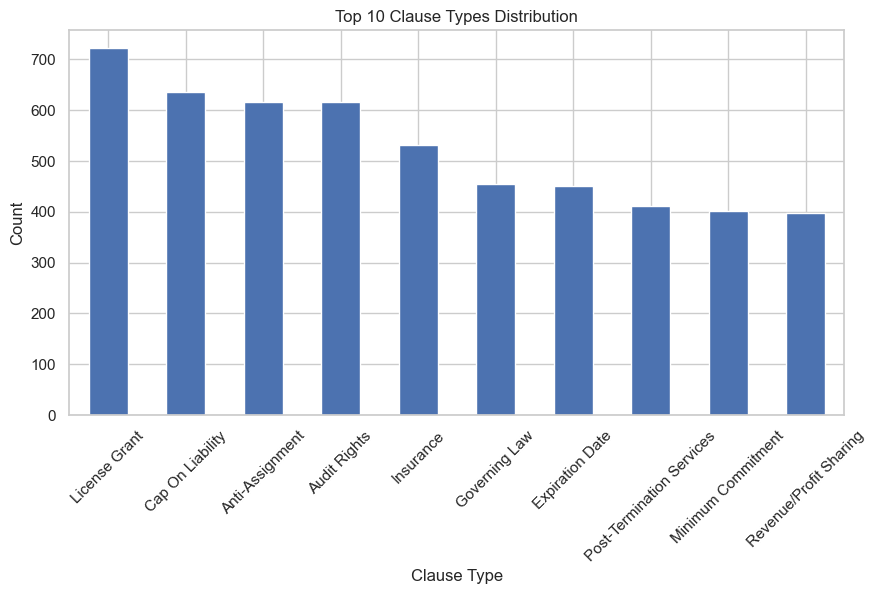

In [6]:
plt.figure(figsize=(10, 5))
df["label"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Clause Types Distribution")
plt.xlabel("Clause Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [7]:
df["word_count"] = df["clause_text"].apply(lambda x: len(x.split()))

df["word_count"].describe()


count    9698.000000
mean       57.117241
std        47.403026
min         6.000000
25%        28.000000
50%        45.000000
75%        71.000000
max       703.000000
Name: word_count, dtype: float64

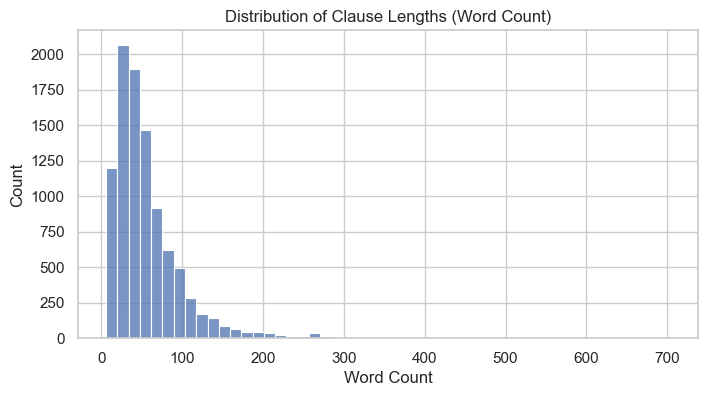

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df["word_count"], bins=50)
plt.title("Distribution of Clause Lengths (Word Count)")
plt.xlabel("Word Count")
plt.show()


In [9]:
short_clauses = df[df["word_count"] < 10]
long_clauses = df[df["word_count"] > 100]

print("Very short clauses:", len(short_clauses))
print("Very long clauses:", len(long_clauses))


Very short clauses: 283
Very long clauses: 1127


In [10]:
RISK_KEYWORDS = {
    "high": ["penalty", "terminate immediately", "unlimited liability"],
    "medium": ["terminate", "liability", "damages"],
    "low": ["notice", "confidential"]
}

def contains_risk_keyword(text):
    text = text.lower()
    for level in RISK_KEYWORDS:
        for word in RISK_KEYWORDS[level]:
            if word in text:
                return level
    return "none"

df["risk_keyword_level"] = df["clause_text"].apply(contains_risk_keyword)

df["risk_keyword_level"].value_counts()


risk_keyword_level
none      6934
medium    1963
low        763
high        38
Name: count, dtype: int64

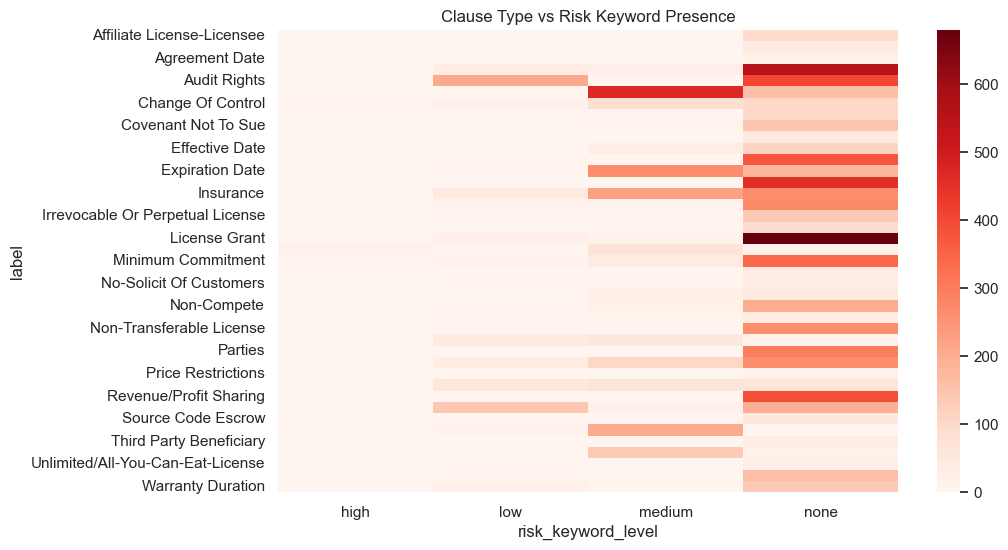

In [11]:
pivot = pd.crosstab(
    df["label"],
    df["risk_keyword_level"]
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap="Reds")
plt.title("Clause Type vs Risk Keyword Presence")
plt.show()


In [12]:
df.sample(5)[["label", "clause_text"]]


,label,clause_text
8177,Ip Ownership Assignment,sanofi shall transfer and assign and shall ens...
3801,Irrevocable Or Perpetual License,i subject to the terms and conditions of this ...
9021,Rofr/Rofo/Rofn,if however adaptimmune limited timely exercise...
673,Anti-Assignment,any unauthorized attempt to assign or delegate...
7258,No-Solicit Of Customers,marketing affiliate shall not directly or indi...


## Key EDA Insights

- Clause distribution is highly imbalanced, with a few clause types dominating.
- Most clauses fall between 15–80 words.
- Risk-related keywords appear frequently in termination and liability clauses.
- Short clauses (<10 words) are often noisy and were filtered.
- EDA informed model selection, truncation length, and risk logic.
